In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load file Excel
df = pd.read_excel("ML Data Wireless Gluten CNN.xlsx")
# df = pd.read_excel("ML Large Motion Data Wireless Gluten CNN.xlsx")
# df = pd.read_excel("ML Small Motion Data Wireless Gluten CNN.xlsx")
df.head()

,Category,Time (s),R/R0
0,Finger,0.04,1.00000
1,Finger,0.08,1.00158
2,Finger,0.12,1.00411
3,Finger,0.16,1.00757
4,Finger,0.20,1.02183


In [2]:
# Normalisasi sinyal agar berada dalam rentang 0-1
df["R/R0"] = (df["R/R0"] - df["R/R0"].min()) / (df["R/R0"].max() - df["R/R0"].min())

<Figure size 1200x600 with 0 Axes>

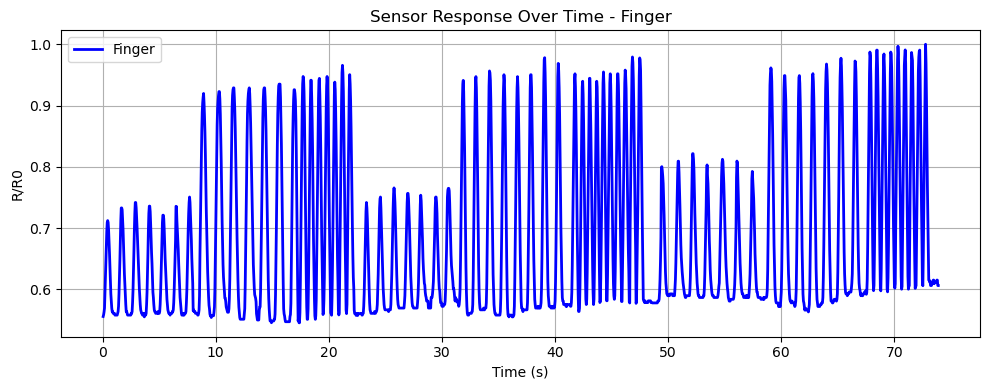

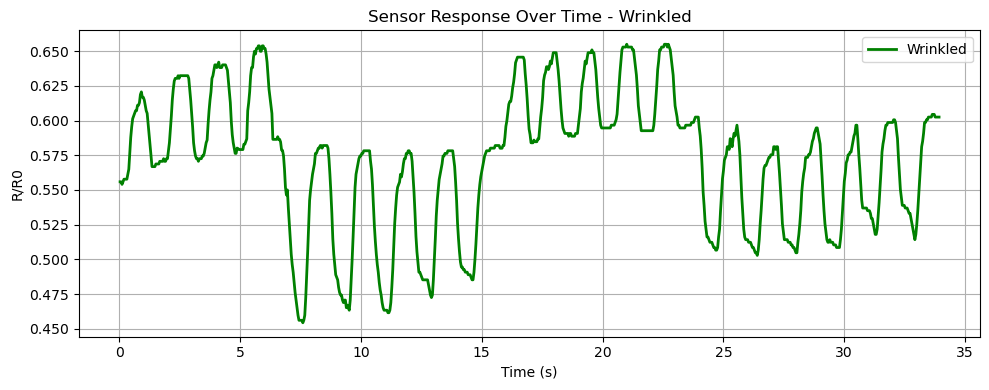

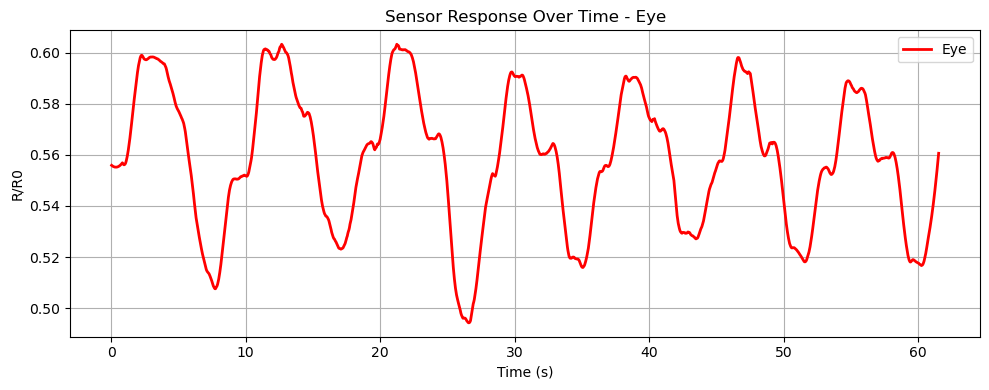

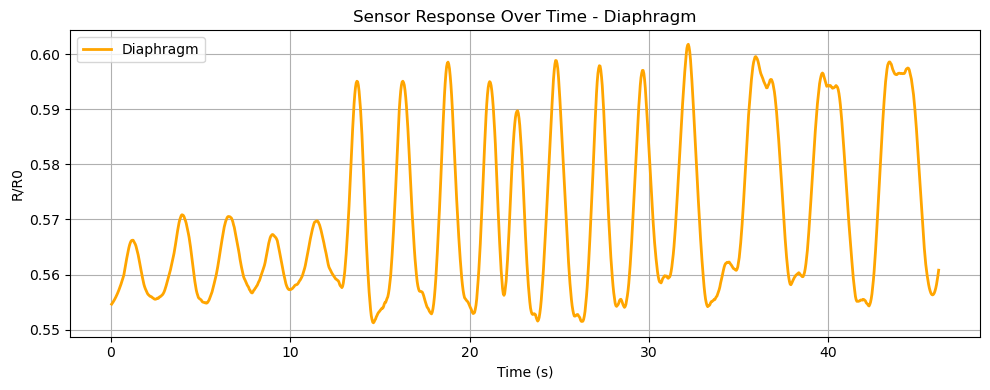

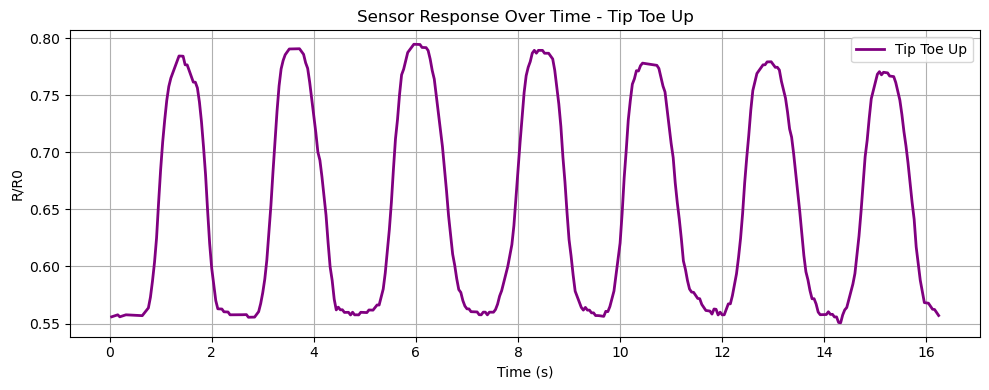

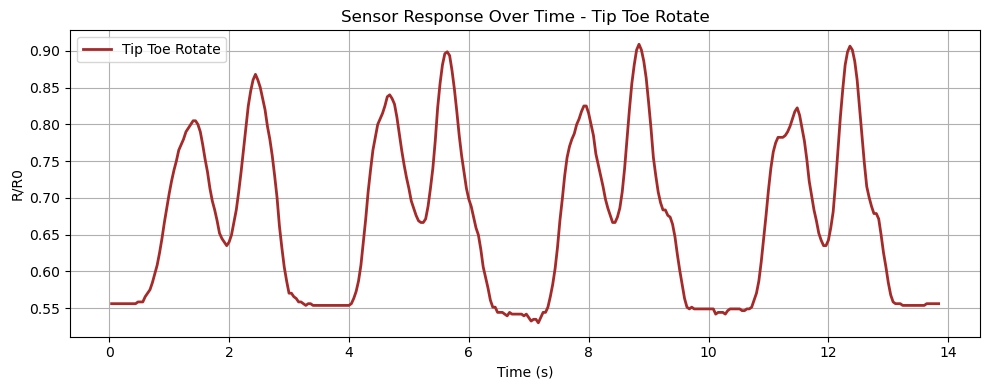

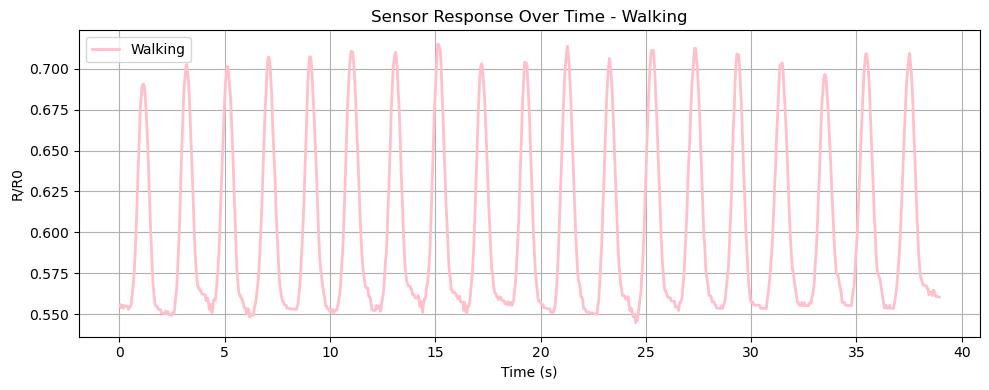

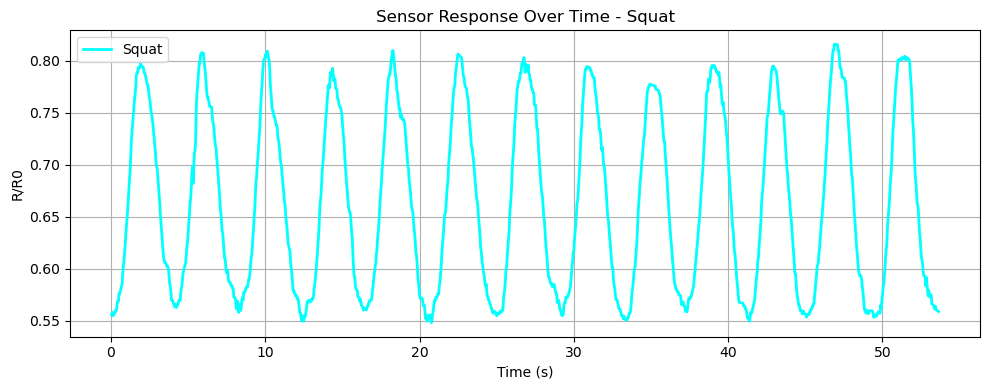

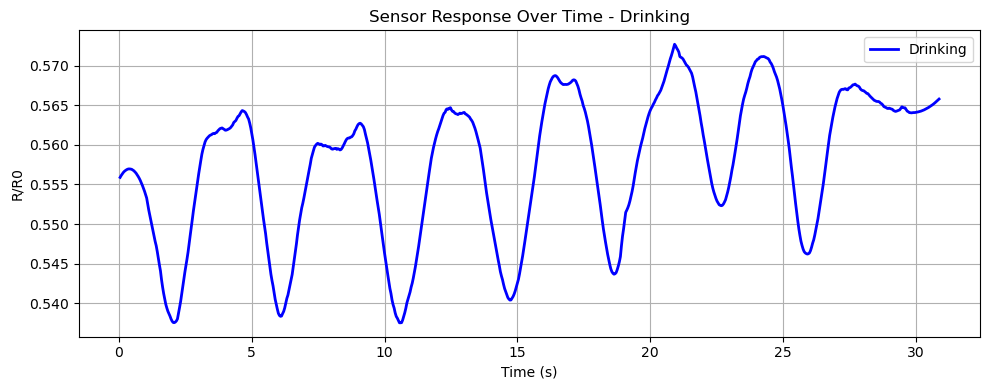

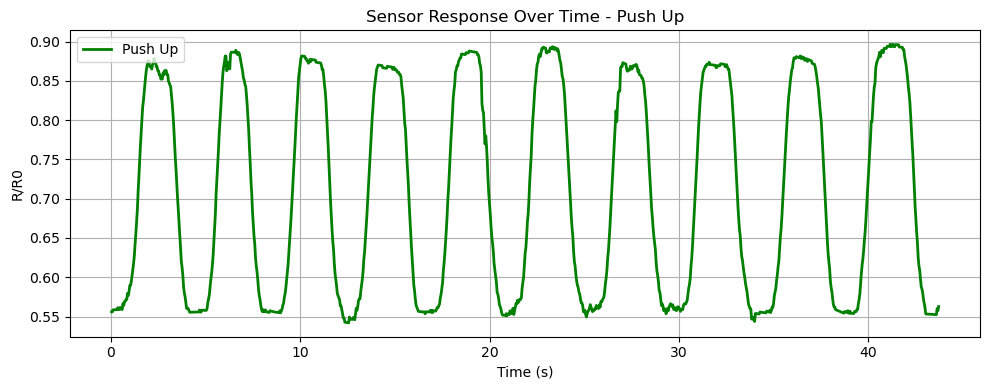

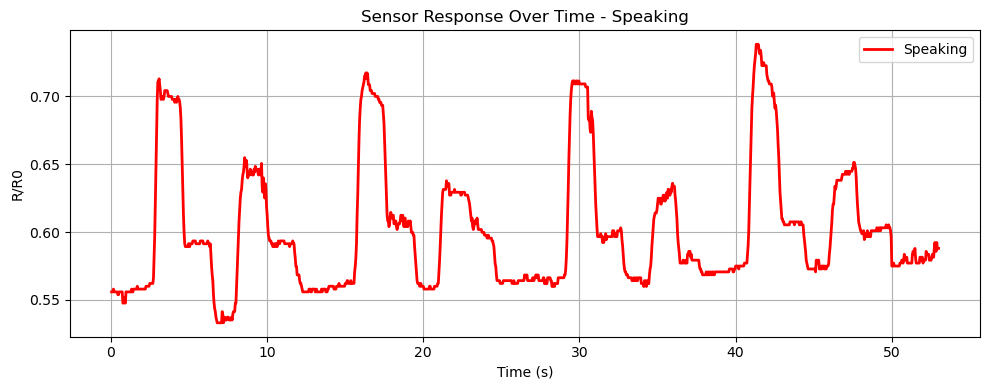

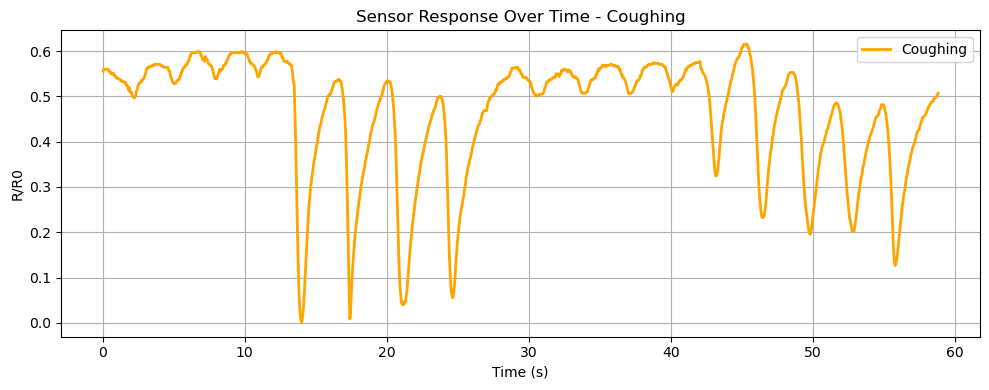

In [3]:
# Siapkan daftar warna berbeda untuk kategori
available_colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown', 'pink', 'cyan']
unique_categories = df["Category"].unique()
color_map = {cat: available_colors[i % len(available_colors)] for i, cat in enumerate(unique_categories)}

# Plot gabungan semua kategori
plt.figure(figsize=(12, 6))

# Buat grafik terpisah per kategori
for category in unique_categories:
    filtered_df = df[df["Category"] == category]
    plot_color = color_map.get(category, "black")
    
    plt.figure(figsize=(10, 4))
    plt.plot(
        filtered_df["Time (s)"], 
        filtered_df["R/R0"], 
        label=category, 
        color=plot_color, 
        linewidth=2
    )
    plt.xlabel("Time (s)")
    plt.ylabel("R/R0")
    plt.title(f"Sensor Response Over Time - {category}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

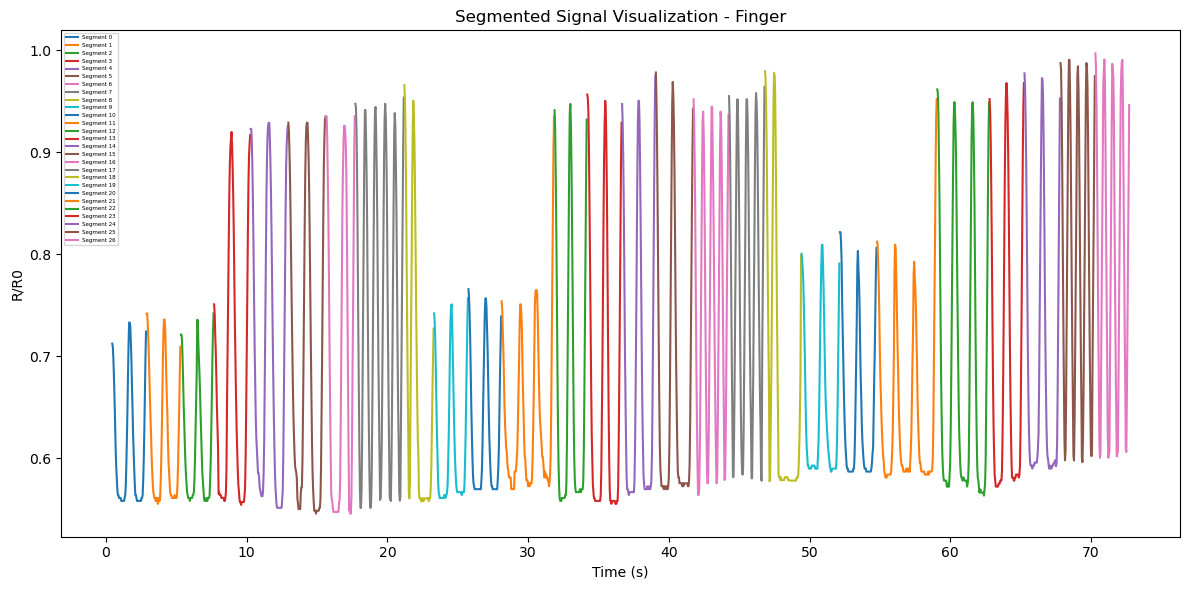

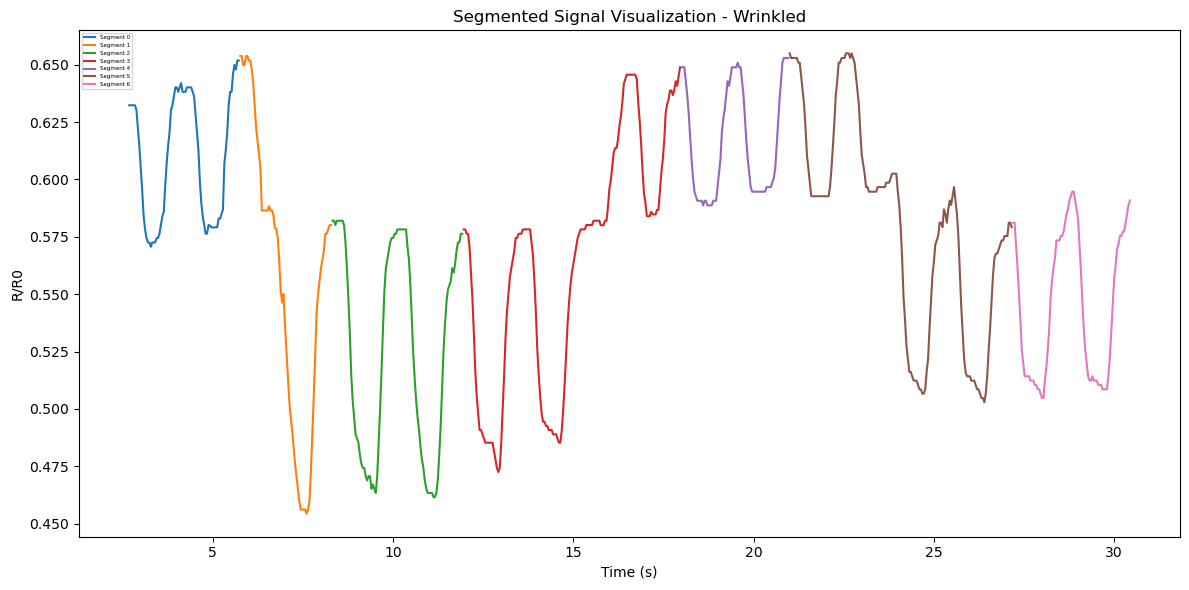

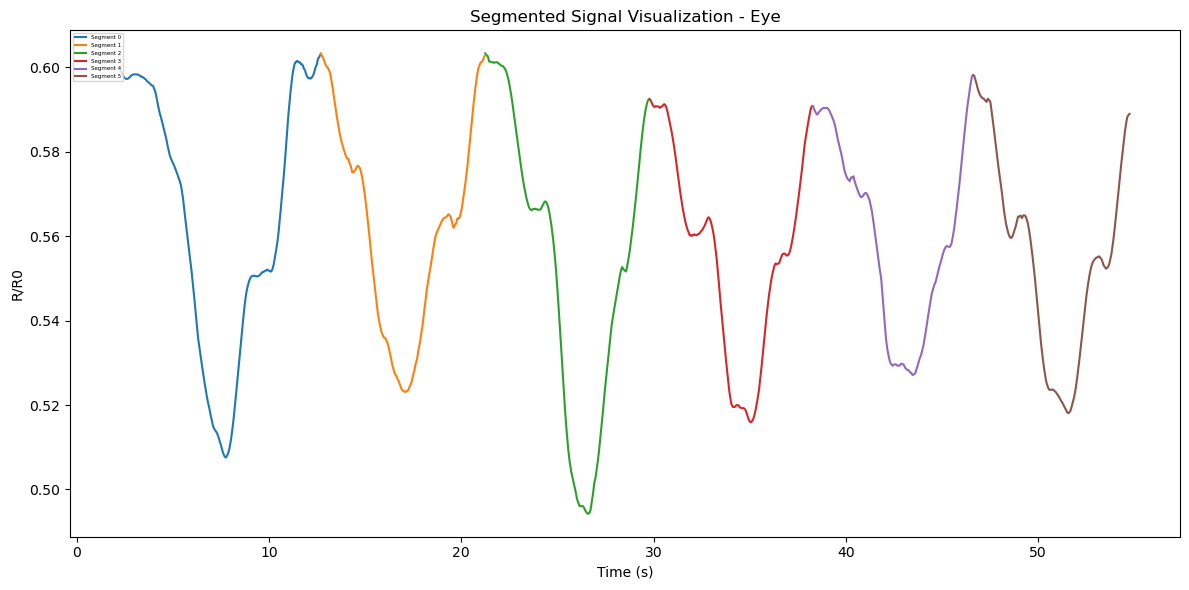

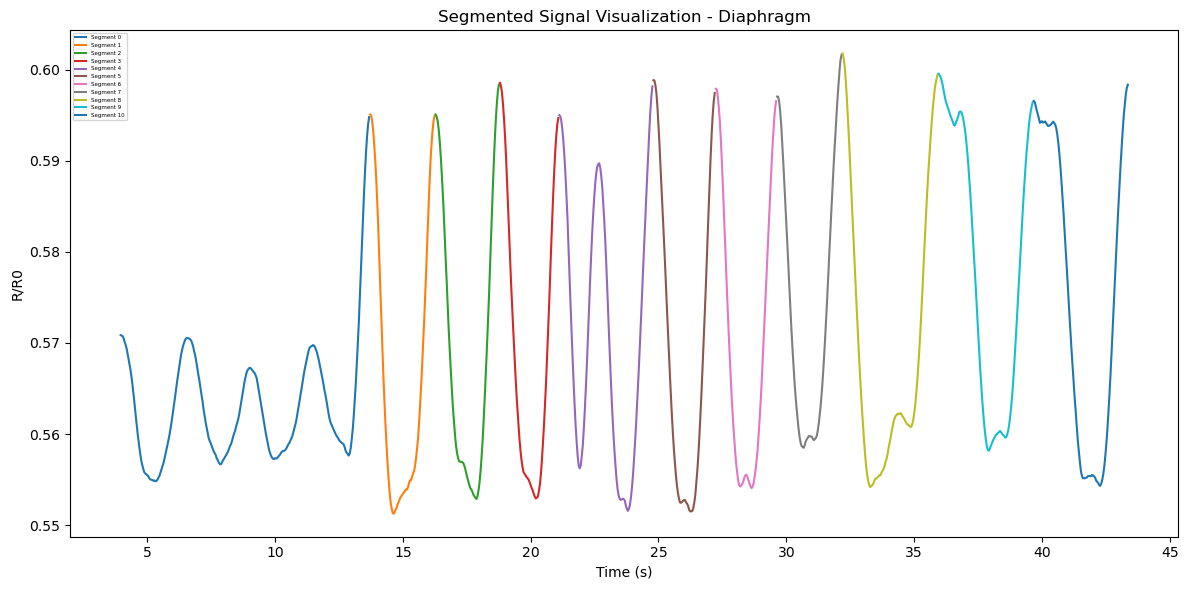

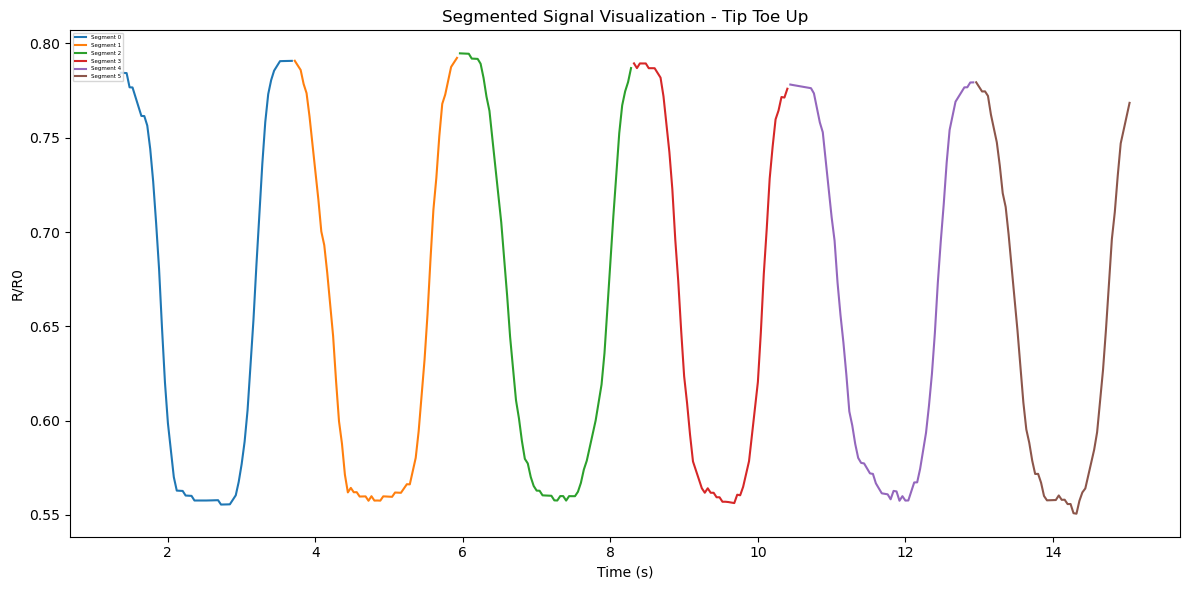

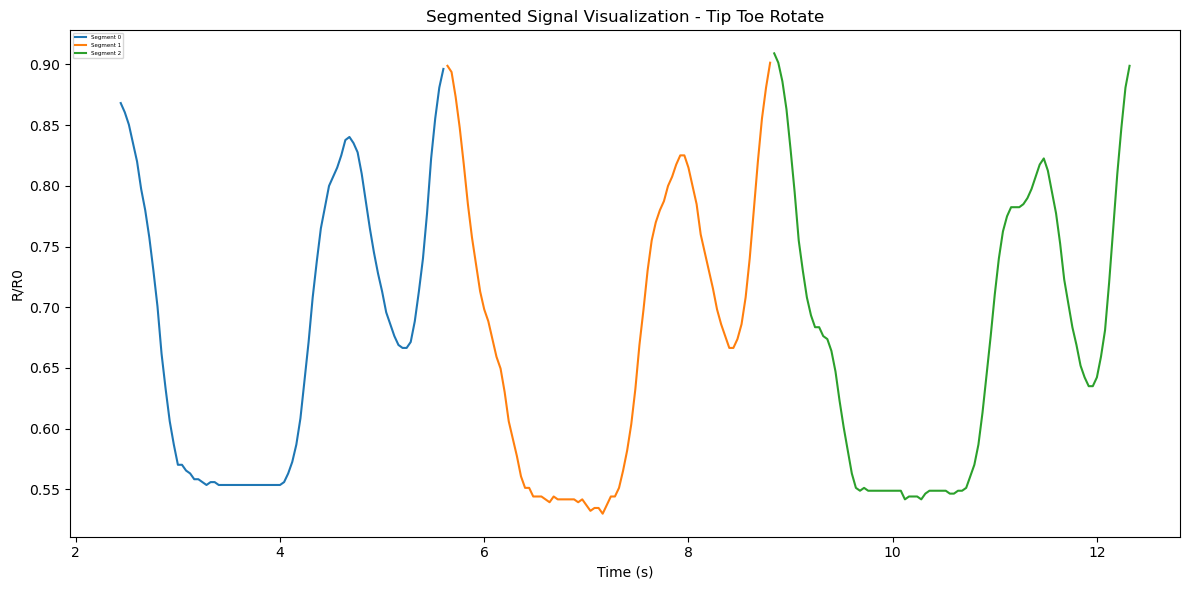

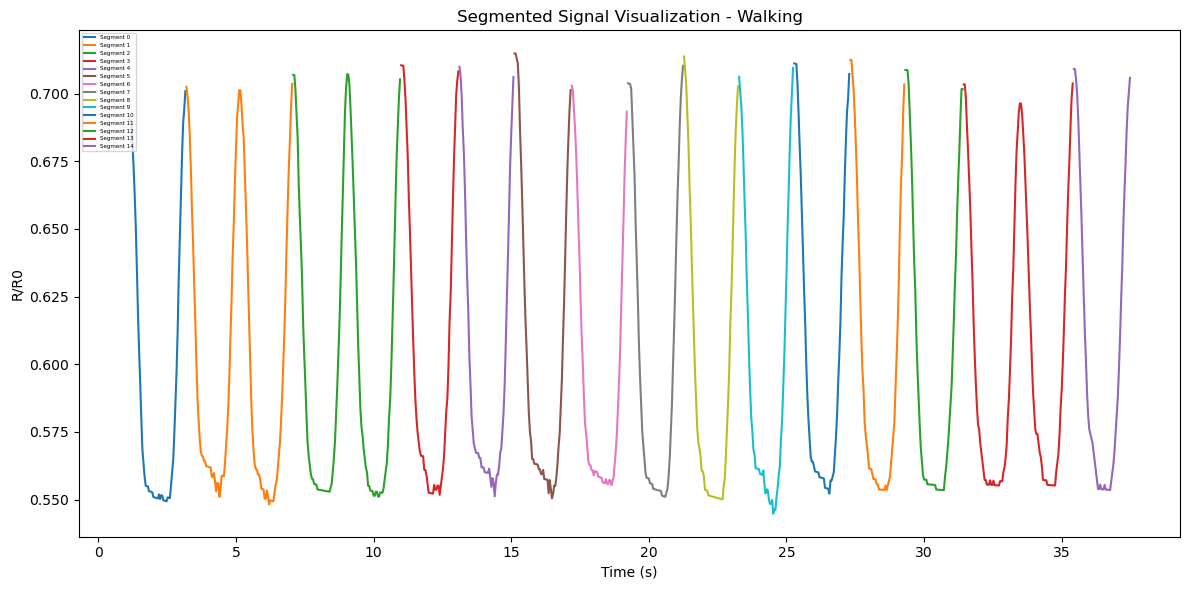

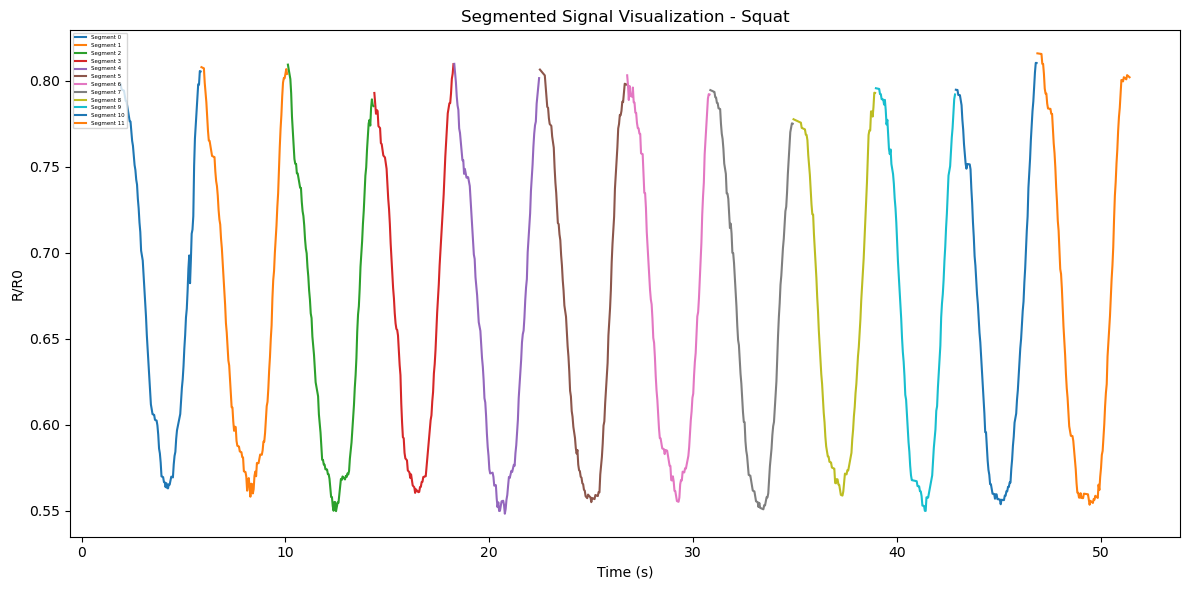

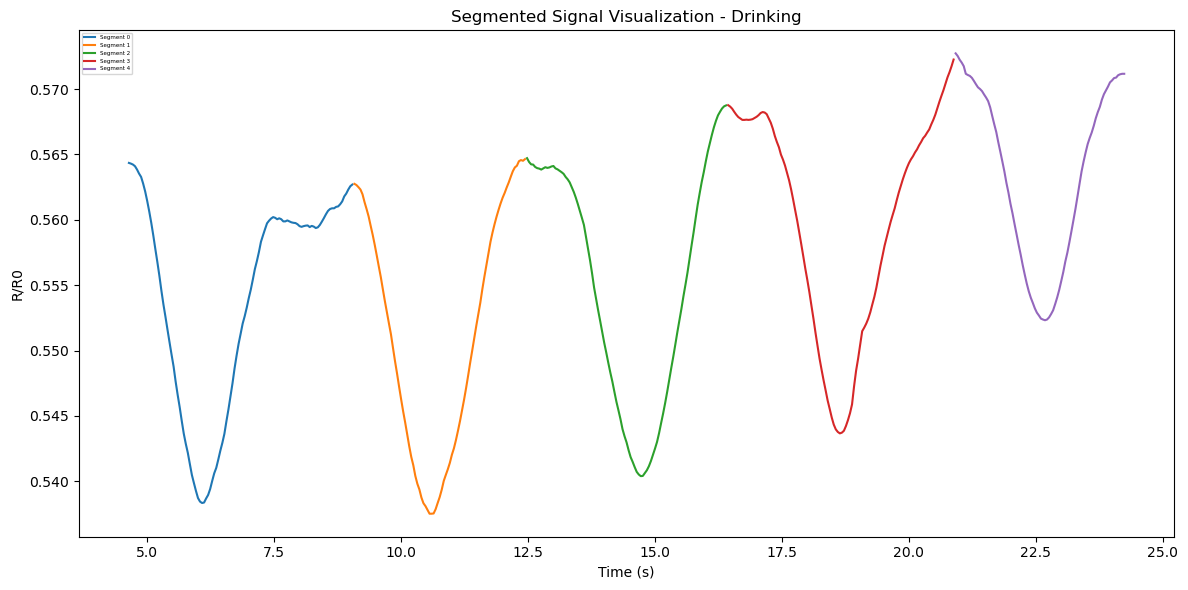

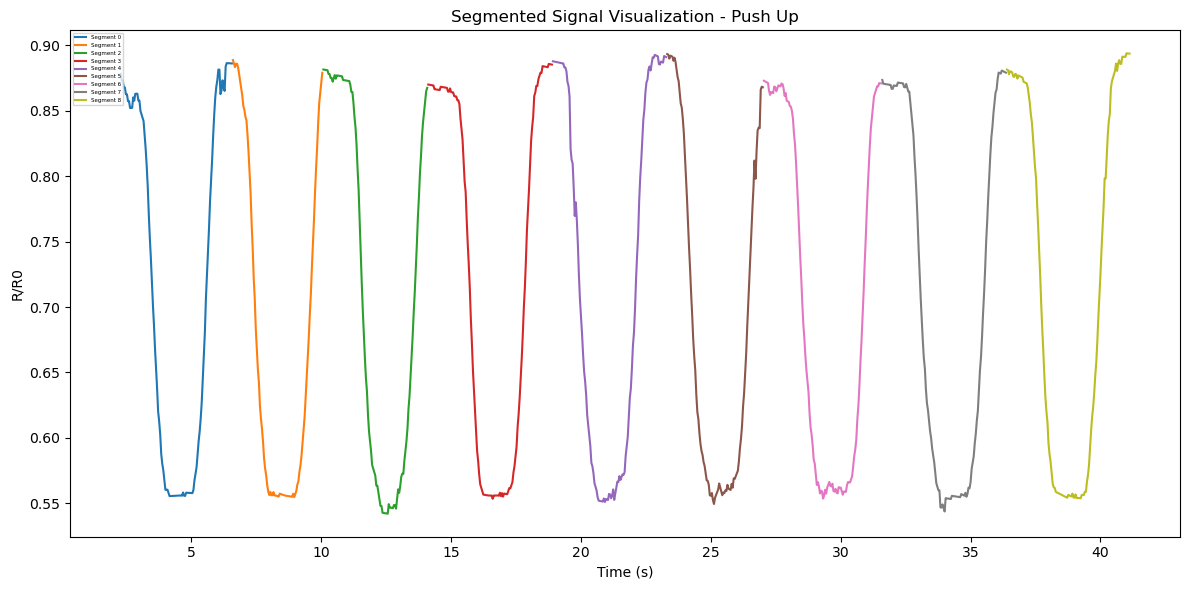

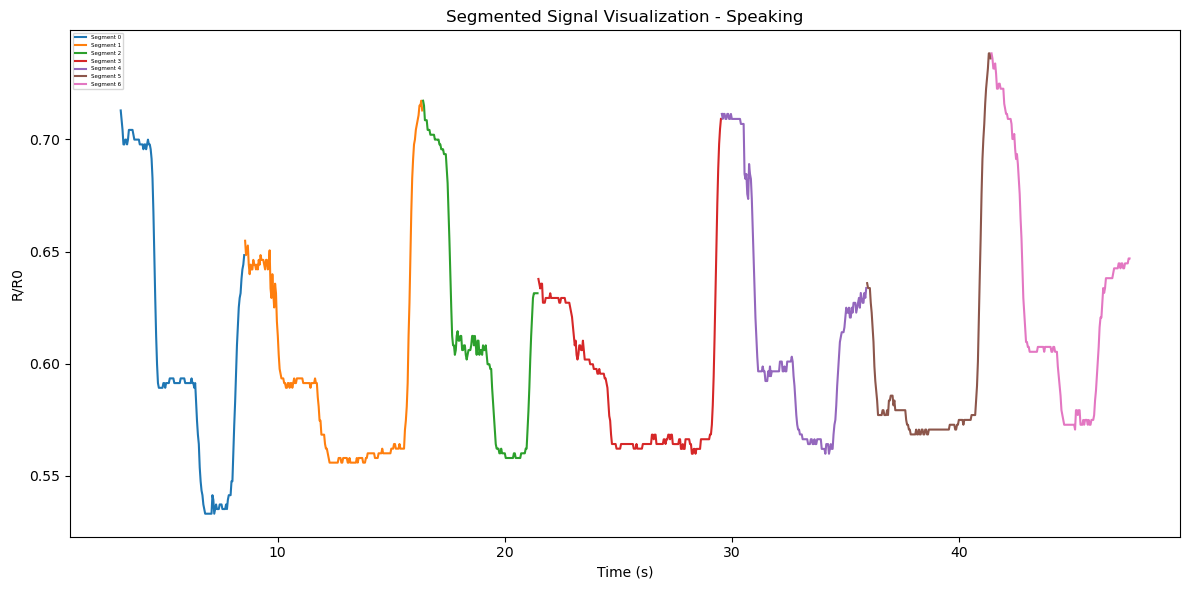

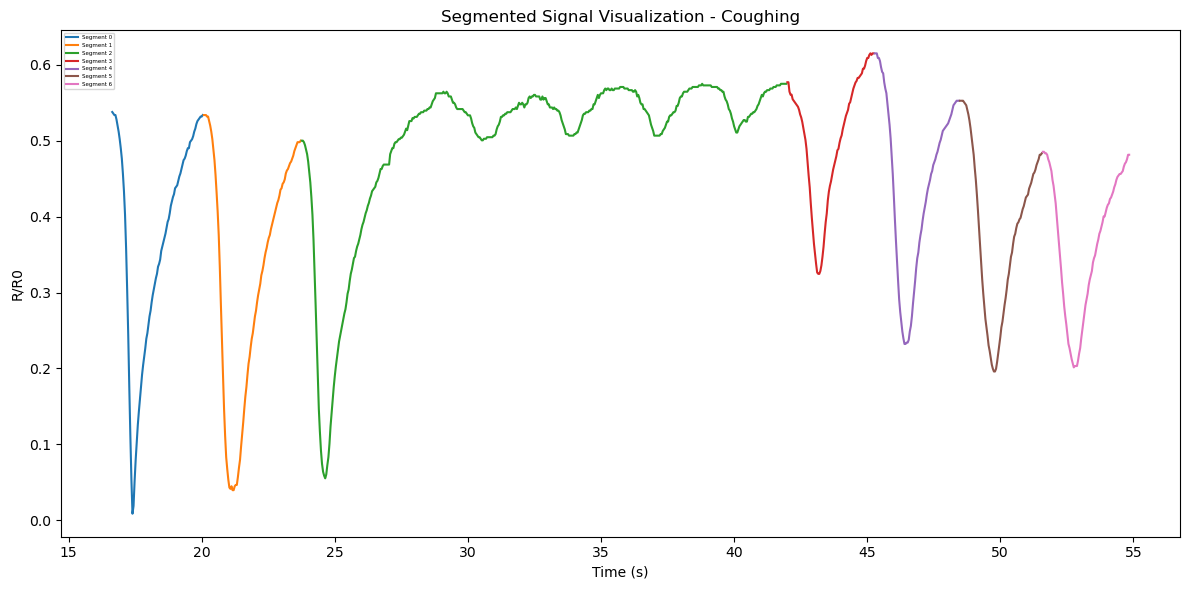

In [4]:
from scipy.signal import find_peaks

# Fungsi deteksi peaks dan valleys
def find_peaks_and_valleys(signal, distance=100):
    peaks, _ = find_peaks(signal, prominence=np.std(signal), distance=distance)
    valleys, _ = find_peaks(-signal, prominence=np.std(signal), distance=distance)
    return peaks, valleys

# Segmentasi berdasarkan kategori dengan windowing dari peak ke peak yang mengandung satu valley
segment_data = []

for category in unique_categories:
    plt.figure(figsize=(12, 6))
    filtered_df = df[df["Category"] == category].copy()
    time_fil = filtered_df["Time (s)"].values
    signal_fil = filtered_df["R/R0"].values
    peaks, valleys = find_peaks_and_valleys(signal_fil, distance=50)

    for i in range(len(peaks) - 1):
        start_idx = peaks[i]
        end_idx = peaks[i + 1]
        closest_valley = valleys[(valleys > start_idx) & (valleys < end_idx)]
        selected_valley = closest_valley[0] if len(closest_valley) > 0 else None

        segment_data.append({
            "Category": category,
            "Start_Time": time_fil[start_idx],
            "End_Time": time_fil[end_idx],
            "Peak_Value": signal_fil[end_idx],
            "Valley_Value": signal_fil[selected_valley] if selected_valley is not None else None,
            "Segment_ID": i
        })

        plt.plot(time_fil[start_idx:end_idx], signal_fil[start_idx:end_idx], label=f"Segment {i}")

    plt.xlabel("Time (s)")
    plt.ylabel("R/R0")
    plt.title(f"Segmented Signal Visualization - {category}")
    plt.legend(loc="upper left", fontsize=4)
    plt.tight_layout()
    plt.show()

# Konversi ke DataFrame
segmented_df = pd.DataFrame(segment_data)

In [5]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import os
import random
import tensorflow as tf

def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
set_seed(42)

# Preprocessing data untuk CNN 1D
features = df[["Time (s)", "R/R0"]].values
labels = df["Category"].astype('category').cat.codes.values

scaler = MinMaxScaler(feature_range=(-1, 1))
features = scaler.fit_transform(features)

# Fungsi untuk membuat windowing data (segmentasi baru)
def create_segmented_sequences(data, labels, window_size, step):
    sequences, target_labels = [], []
    for i in range(0, len(data) - window_size + 1, step):
        sequences.append(data[i:i+window_size])
        target_labels.append(labels[i + window_size - 1])  # Ambil label akhir dari window
    return np.array(sequences), np.array(target_labels)

# Parameter windowing
window_size = 50
step_size = 5
X, y = create_segmented_sequences(features, labels, window_size, step_size)

# Pastikan X memiliki dimensi yang sesuai untuk CNN 1D
if len(X.shape) == 2:
    X = X.reshape(-1, window_size, 1)

# Split data menjadi train & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definisikan model CNN 1D yang lebih optimal
model = Sequential([
    Conv1D(filters=256, kernel_size=5, activation='relu', padding='same', input_shape=(window_size, X.shape[2])),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    
    GlobalAveragePooling1D(),  # Alternatif Flatten yang lebih stabil
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(np.unique(labels)), activation='softmax')
])

# Optimizer dan scheduler
initial_learning_rate = 0.001
optimizer = Adam(learning_rate=initial_learning_rate)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

# Compile model
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Latih model dengan batch size yang lebih optimal
batch_size = 64
# history = model.fit(X_train,y_train,epochs=500,batch_size=batch_size,validation_data=(X_test, y_test),callbacks=[reduce_lr, early_stop])
history = model.fit(X_train,y_train,epochs=500,batch_size=batch_size,validation_data=(X_test, y_test))
#hasil 85.37%

# === Evaluate ===
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

Epoch 1/500


c:\Users\nitan\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.2101 - loss: 2.2695 - val_accuracy: 0.1224 - val_loss: 2.4067
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3665 - loss: 1.7367 - val_accuracy: 0.1224 - val_loss: 2.4578
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4167 - loss: 1.5436 - val_accuracy: 0.1224 - val_loss: 2.6415
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4974 - loss: 1.3507 - val_accuracy: 0.1224 - val_loss: 2.9099
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5462 - loss: 1.2633 - val_accuracy: 0.1224 - val_loss: 3.1419
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5645 - loss: 1.1663 - val_accuracy: 0.1224 - val_loss: 3.4240
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6166 - loss: 1.0707 - val_accuracy: 0.1224 - val_loss: 3.7400
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6394 - loss: 0.9958 - val_accuracy: 0.1224 - val_l

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9698 - loss: 0.1210
Test Accuracy: 0.9675
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Normalized confusion matrix:
[[0.94 0.   0.   0.04 0.   0.   0.02 0.   0.   0.   0.   0.  ]
 [0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.06 0.93 0.   0.   0.   0.   0.   0.   0.   0.02]
 [0.   0.   0.   0.   1.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   1.   0.   0.   0.   0.   0.   0.  ]
 [0.02 0.03 0.03 0.   0.   0.02 0.91 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.98 0.   0.   0.02 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.92 0.08 0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   1.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.03 0.   0.   0.03 0.   0.95 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  ]]


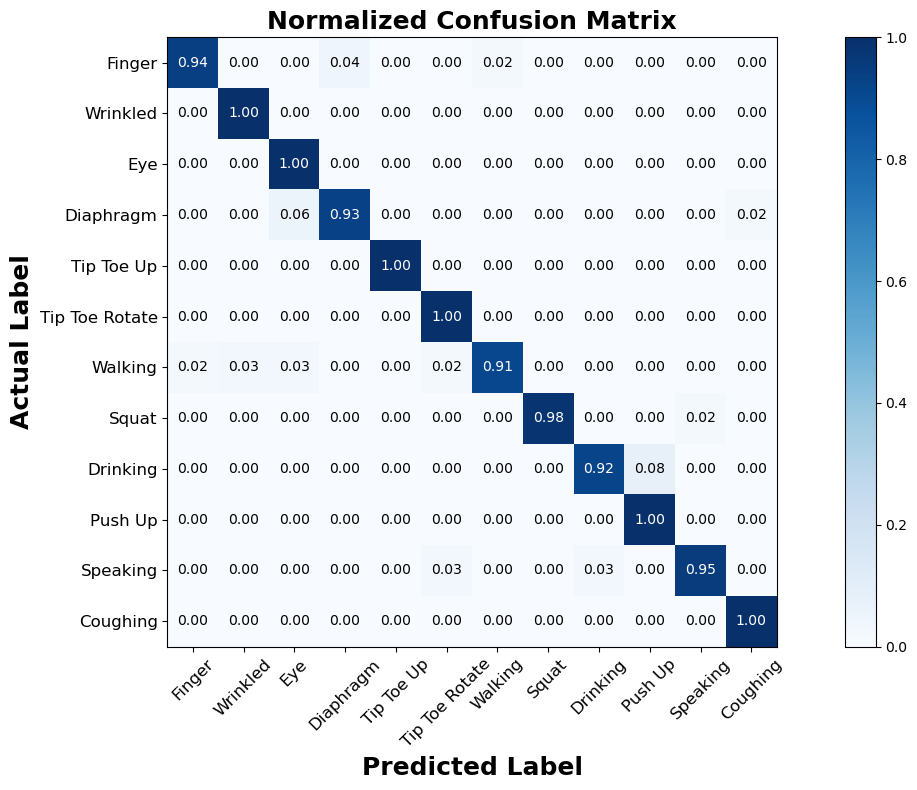

Classification Report:
                precision    recall  f1-score   support

        Finger       0.98      0.94      0.96        52
      Wrinkled       0.96      1.00      0.98        48
           Eye       0.86      1.00      0.93        31
     Diaphragm       0.96      0.93      0.94        54
    Tip Toe Up       1.00      1.00      1.00        70
Tip Toe Rotate       0.96      1.00      0.98        44
       Walking       0.98      0.91      0.94        64
         Squat       1.00      0.98      0.99        50
      Drinking       0.92      0.92      0.92        13
       Push Up       0.93      1.00      0.97        14
      Speaking       0.97      0.95      0.96        39
      Coughing       0.98      1.00      0.99        44

      accuracy                           0.97       523
     macro avg       0.96      0.97      0.96       523
  weighted avg       0.97      0.97      0.97       523

Test Accuracy : 96.75%


In [ ]:
from sklearn.metrics import  classification_report,confusion_matrix

# Evaluasi model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

# Prediksi data uji
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Normalisasi confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)
cm_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
cm_normalized = np.around(cm_normalized, 2)
classes = df['Category'].unique()

# Print confusion matrix setelah normalisasi
print("Normalized confusion matrix:")
print(cm_normalized)

# Plot confusion matrix setelah normalisasi
plt.figure(figsize=(14, 8))
plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Normalized Confusion Matrix', fontsize=18, weight='bold')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, fontsize=12, rotation = 45)
plt.yticks(tick_marks, classes, fontsize=12)

# Menampilkan angka pada confusion matrix
for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        plt.text(j, i, format(cm_normalized[i, j], '.2f'),
                 ha="center", va="center",
                 color="white" if cm_normalized[i, j] > 0.5 else "black")

plt.ylabel('Actual Label', fontsize=18, weight='bold')
plt.xlabel('Predicted Label', fontsize=18, weight='bold')
plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=classes))

print("Test Accuracy : {:.2f}%".format(accuracy*100))

In [10]:
# Menampilkan train loss & accuracy dalam bentuk persentase
final_train_loss = history.history['loss'][-1] * 100
final_train_accuracy = history.history['accuracy'][-1] * 100
final_val_loss = history.history['val_loss'][-1] * 100
final_val_accuracy = history.history['val_accuracy'][-1] * 100

print(f"Final Train Loss: {final_train_loss:.2f}%")
print(f"Final Train Accuracy: {final_train_accuracy:.2f}%")
print(f"Final Validation Loss: {final_val_loss:.2f}%")
print(f"Final Validation Accuracy: {final_val_accuracy:.2f}%")

Final Train Loss: 3.35%
Final Train Accuracy: 98.61%
Final Validation Loss: 13.22%
Final Validation Accuracy: 96.75%


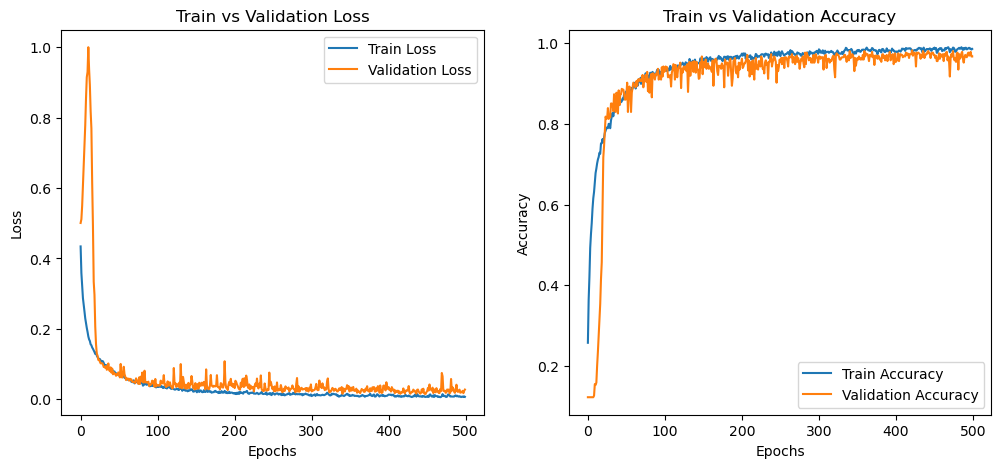

In [7]:
max_loss = max(max(history.history['loss']), max(history.history['val_loss']))  # Ambil nilai max loss
history.history['loss'] = [x / max_loss for x in history.history['loss']]  # Normalisasi
history.history['val_loss'] = [x / max_loss for x in history.history['val_loss']]  # Normalisasi


# Plot train loss & accuracy mulai dari epoch 1
epochs_range = range(1, len(history.history['loss']) + 1)
plt.figure(figsize=(12, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy')
plt.legend(fontsize=10)
plt.show()


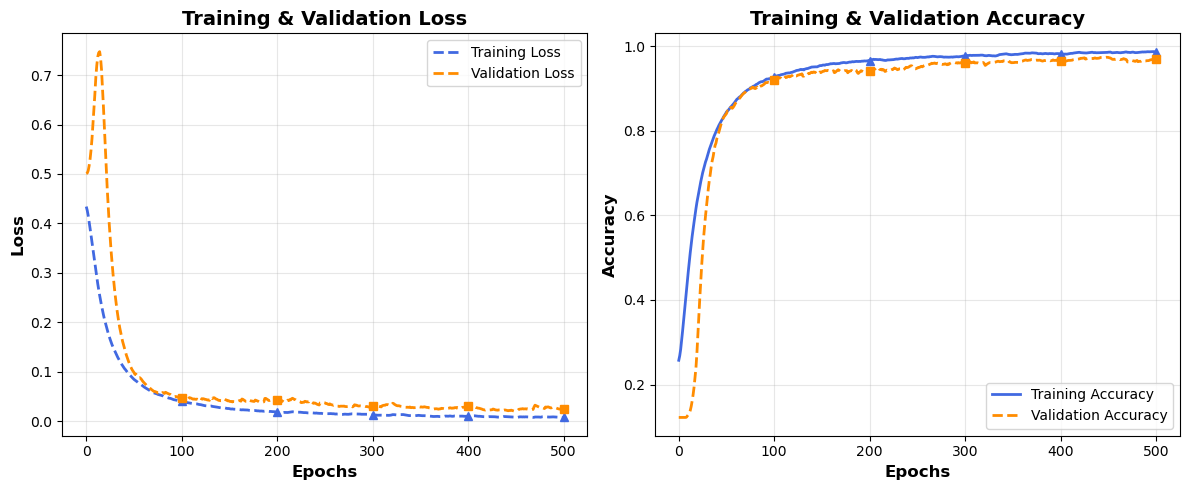

In [8]:
# Fungsi untuk moving average
def smooth_curve(data, factor=0.9):
    smoothed = []
    last = data[0]  # Mulai dari nilai pertama
    for point in data:
        last = factor * last + (1 - factor) * point  # Eksponensial moving average
        smoothed.append(last)
    return smoothed

loss_smooth = smooth_curve(history.history["loss"])
val_loss_smooth = smooth_curve(history.history["val_loss"])
acc_smooth = smooth_curve(history.history["accuracy"])
val_acc_smooth = smooth_curve(history.history["val_accuracy"])

plt.figure(figsize=(12, 5))

# Epoch yang ingin Anda beri marker
marker_epochs = [100, 200, 300, 400, 500]

marker_loss = [loss_smooth[epoch - 1] for epoch in marker_epochs]
marker_val_loss = [val_loss_smooth[epoch - 1] for epoch in marker_epochs]
marker_acc = [acc_smooth[epoch - 1] for epoch in marker_epochs]
marker_val_acc = [val_acc_smooth[epoch - 1] for epoch in marker_epochs]

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(loss_smooth, label="Training Loss", color="royalblue", linewidth=2, linestyle='--')
plt.plot(val_loss_smooth, label="Validation Loss", color="darkorange", linewidth=2, linestyle="--")
plt.xlabel("Epochs", fontsize=12, fontweight="bold")
plt.ylabel("Loss", fontsize=12, fontweight="bold")
plt.title("Training & Validation Loss", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)

# Plot marker pada epoch yang diinginkan
plt.plot(marker_epochs, marker_loss, marker='^', color="royalblue", linestyle='None')  # Marker training loss
plt.plot(marker_epochs, marker_val_loss, marker='s', color="darkorange", linestyle='None')  # Marker validasi loss

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(acc_smooth, label="Training Accuracy", color="royalblue", linewidth=2)
plt.plot(val_acc_smooth, label="Validation Accuracy", color="darkorange", linewidth=2, linestyle="--")
plt.xlabel("Epochs", fontsize=12, fontweight="bold")
plt.ylabel("Accuracy", fontsize=12, fontweight="bold")
plt.title("Training & Validation Accuracy", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)

# Plot marker pada epoch yang diinginkan
plt.plot(marker_epochs, marker_acc, marker='^', color="royalblue", linestyle='None')  # Marker training loss
plt.plot(marker_epochs, marker_val_acc, marker='s', color="darkorange", linestyle='None')  # Marker validasi loss

plt.tight_layout()
plt.show()

In [29]:
# Menampilkan train loss & accuracy dalam bentuk persentase
final_train_loss = loss_smooth[-1] * 100
final_train_accuracy = acc_smooth[-1] * 100
final_val_loss = val_loss_smooth[-1] * 100
final_val_accuracy = val_acc_smooth[-1] * 100

print(f"Final Train Loss: {final_train_loss:.2f}%")
print(f"Final Train Accuracy: {final_train_accuracy:.2f}%")
print(f"Final Validation Loss: {final_val_loss:.2f}%")
print(f"Final Validation Accuracy: {final_val_accuracy:.2f}%")

Final Train Loss: 0.80%
Final Train Accuracy: 98.66%
Final Validation Loss: 2.45%
Final Validation Accuracy: 96.91%
